This Jupyter notebook provides a hands-on supplement to our paper, "Biased spreading in continuous-time quantum walks from unbiased delocalized states:
exact results."

# Click here to start

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.special import jv
import scipy.sparse as sp
from math import pi
import math
import matplotlib.pyplot as plt

# Main code


The following codes for generating and analyzing the data were developed by José M. Villas-Bôas.

In [1]:
# Converts a site index to an array index
def site_to_idx(site, N_sites_half):
    return site + N_sites_half

# Calculates the expectation value of the position
def position_expectation(psi, sites):
    prob_density = np.abs(psi)**2
    return np.sum(sites * prob_density)

# Calculates the standard deviation
def standard_deviation(psi, sites):
    mean_x = position_expectation(psi, sites)
    mean_x2 = np.sum((sites**2) * np.abs(psi)**2)
    variance = mean_x2 - mean_x**2
    return np.sqrt(max(0, variance))

# Calculates the survival probability within a range
def calculate_survival_probability(psi, site_range, sites):
    k0, k1 = site_range
    mask = (sites >= k0) & (sites <= k1)
    return np.sum(np.abs(psi[mask])**2)


# Sets up the Hamiltonian matrix
def setup_hamiltonian(L, alpha, gamma):
    H = sp.lil_matrix((L, L), dtype=complex)
    for i in range(L - 1):
        H[i + 1, i] = -gamma * np.exp(1j * alpha)
        H[i, i + 1] = -gamma * np.exp(-1j * alpha)
    return H.tocsr()

# Creates the initial state vector
def create_initial_state(L, D, N_sites_half):
    psi0 = np.zeros(L, dtype=complex)
    psi0[site_to_idx(0, N_sites_half)] = np.sqrt(1 - D)
    psi0[site_to_idx(1, N_sites_half)] = np.sqrt(D / 2)
    psi0[site_to_idx(-1, N_sites_half)] = np.sqrt(D / 2)
    return psi0

# Runs the numerical simulation
def run_numerical_simulation(H, psi0, t_span, t_eval):
    Hi = -1j * H
    def schrodinger_rhs(t, u):
        return Hi @ u
    sol = solve_ivp(schrodinger_rhs, t_span, psi0,
                    t_eval=t_eval, atol=1e-10, rtol=1e-10, method='DOP853')
    return sol

# Calculates analytical solutions for various times
def calculate_analytical_solutions_t(sites, t_values, params):
    psi_analytical_t = []
    for i, t in enumerate(t_values):
        psi_t = np.array([psi_analytical(x, t, **params) for x in sites])
        psi_analytical_t.append(psi_t)
    print("Cálculo analítico completo.")
    return np.array(psi_analytical_t)

# Calculates the analytical wave function
def psi_analytical(x, t, alpha, gamma, D):
    z = 2 * gamma * t
    jx, jxp1, jxm1 = jv(x, z), jv(x + 1, z), jv(x - 1, z)
    return (np.sqrt(1-D) * (1.0j**x) * jx * np.exp(1j*x*alpha) +
            np.sqrt(D/2) * (1.0j**(x-1)) * jxm1 * np.exp(1j*(x-1)*alpha) +
            np.sqrt(D/2) * (1.0j**(x+1)) * jxp1 * np.exp(1j*(x+1)*alpha))

# Calculates the analytical survival probability
def P_survival(gamma, t, D, alpha):
    x = 2 * gamma * t
    term1 = jv(0, x)**2
    term2 = 2 * (1 - D * np.sin(alpha)**2) * jv(1, x)**2
    term3 = D * jv(2, x)**2
    term4 = -2 * D * np.cos(2 * alpha) * jv(0, x) * jv(2, x)
    return term1 + term2 + term3 + term4

# Calculates the analytical standard deviation
def Std_Ana(t, D, alpha, gamma):
    term_in_sqrt = D + (gamma**2 * t**2) * ((2 - D) + 2 * D * (4 * D - 3) * np.sin(alpha)**2)
    return np.sqrt(term_in_sqrt)

# Calculates the expected value of velocity
def mean_v(D, alpha, gamma):
    return 2 * gamma * np.sin(alpha) * np.sqrt(2 * D * (1 - D))

# Calculates the Mean Squared Displacement (MSD)
def MSD(t, D, alpha, gamma):
    return D + (gamma**2 * t**2) * ((2 - D) + 2 * D * np.sin(alpha)**2)

## Figure 1

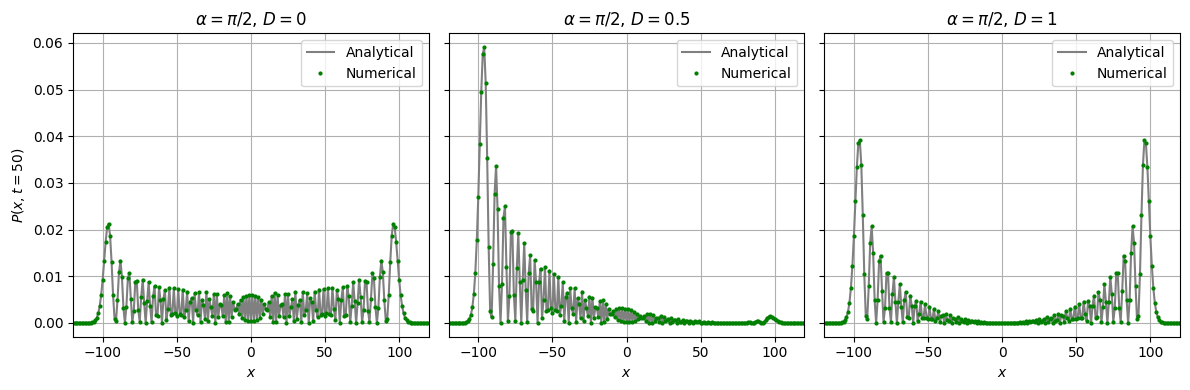

In [ ]:
def plot_Prob_matplotlib():
    t_final = 50.0
    t_span = [0.0, t_final]
    t_values = np.linspace(t_span[0], t_span[1], 501)

    N_sites_half = int(np.floor(4 * t_final))
    sites = np.arange(-N_sites_half, N_sites_half + 1)
    L = len(sites)

    alpha = np.pi * 0.5
    H = setup_hamiltonian(L, alpha=alpha, gamma=1.0)
    psi0_D_00 = create_initial_state(L, 0.0, N_sites_half)
    psi0_D_05 = create_initial_state(L, 0.5, N_sites_half)
    psi0_D_10 = create_initial_state(L, 1.0, N_sites_half)

    sol_D00 = run_numerical_simulation(H, psi0_D_00, t_span, t_values)
    sol_D05 = run_numerical_simulation(H, psi0_D_05, t_span, t_values)
    sol_D10 = run_numerical_simulation(H, psi0_D_10, t_span, t_values)

    Psi_A_D00=psi_analytical(sites, t_final, alpha, 1.0, 0.0)
    Psi_A_D05=psi_analytical(sites, t_final, alpha, 1.0, 0.5)
    Psi_A_D10=psi_analytical(sites, t_final, alpha, 1.0, 1.0)

    psi_num_final_D00 = sol_D00.y[:, -1]
    psi_num_final_D05 = sol_D05.y[:, -1]
    psi_num_final_D10 = sol_D10.y[:, -1]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

    # Plot for D=0.0
    axes[0].plot(sites, np.abs(Psi_A_D00)**2, label='Analytical', color='gray')
    axes[0].plot(sites, np.abs(psi_num_final_D00)**2, 'o', markersize=2, label='Numerical', color='green')
    axes[0].set_xlabel(r'$x$')
    axes[0].set_ylabel(r'$P(x,t=50)$')
    axes[0].set_title(r'$\alpha=\pi/2$, $D=0$')
    axes[0].legend()
    axes[0].grid(True)
    axes[0].set_xlim([-120, 120])

    # Plot for D=0.5
    axes[1].plot(sites, np.abs(Psi_A_D05)**2, label='Analytical', color='gray')
    axes[1].plot(sites, np.abs(psi_num_final_D05)**2, 'o', markersize=2, label='Numerical', color='green')
    axes[1].set_xlabel(r'$x$')
    axes[1].set_title(r'$\alpha=\pi/2$, $D=0.5$')
    axes[1].legend()
    axes[1].grid(True)
    axes[1].set_xlim([-120, 120])

    # Plot for D=1.0
    axes[2].plot(sites, np.abs(Psi_A_D10)**2, label='Analytical', color='gray')
    axes[2].plot(sites, np.abs(psi_num_final_D10)**2, 'o', markersize=2, label='Numerical', color='green')
    axes[2].set_xlabel(r'$x$')
    axes[2].set_title(r'$\alpha=\pi/2$, $D=1$')
    axes[2].legend()
    axes[2].grid(True)
    axes[2].set_xlim([-120, 120])

    plt.tight_layout()
    plt.show()

plot_Prob_matplotlib()

## Figure 2

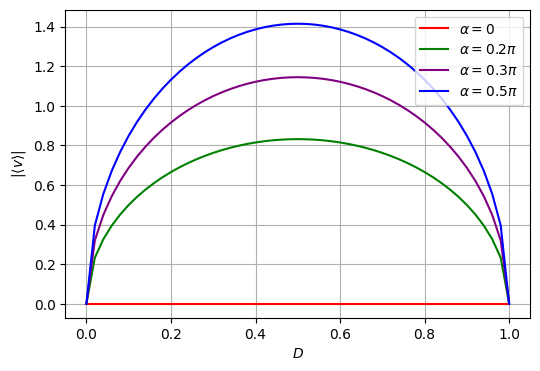

In [ ]:
def Plot_Mean_v_matplotlib():
    Dv = np.linspace(0, 1, 51)
    mean_v_a0 = mean_v(Dv, 0, 1.0)
    mean_v_a02 = mean_v(Dv, 0.2*np.pi, 1.0)
    mean_v_a03 = mean_v(Dv, 0.3*np.pi, 1.0)
    mean_v_a05 = mean_v(Dv, 0.5*np.pi, 1.0)

    plt.figure(figsize=(6, 4))

    plt.plot(Dv, mean_v_a0, label=r"$\alpha=0$", color='red') # Changed from red to blue
    plt.plot(Dv, mean_v_a02, label=r"$\alpha=0.2\pi$", color='green') # Changed from orange to green
    plt.plot(Dv, mean_v_a03, label=r"$\alpha=0.3\pi$", color='purple') # Changed from green to purple
    plt.plot(Dv, mean_v_a05, label=r"$\alpha=0.5\pi$", color='blue') # Changed from blue to red


    plt.xlabel(r'$D$')
    plt.ylabel(r"$|\langle v \rangle|$")
    plt.legend()
    plt.grid(True)
    plt.show()

Plot_Mean_v_matplotlib()

## Figure 3

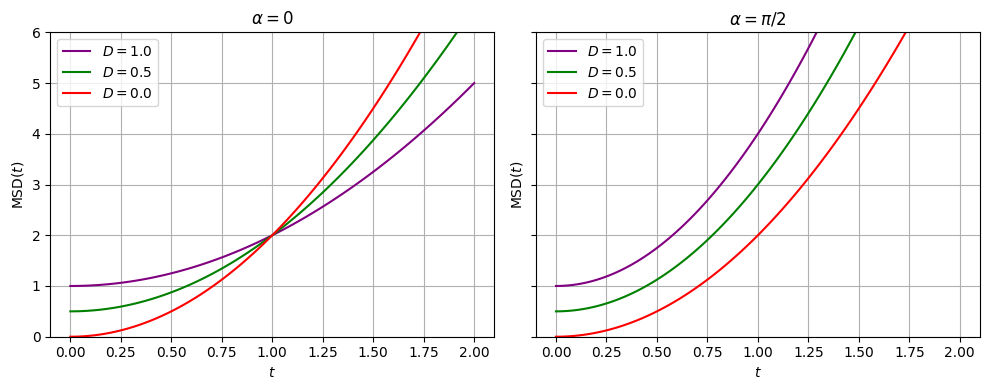

In [ ]:
def Plot_MSD_vs_t2_matplotlib():
    gamma = 1.0
    tv = np.linspace(0, 2, 101)
    D_vals = [0.0, 0.5, 1.0]
    alphas = [np.pi/2, 0.0]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

    colors = {0.0: 'red', 0.5: 'green', 1.0: 'purple'}

    # Plot for alpha = 0.0
    for D in sorted(D_vals, reverse=True):
        msd_vals = MSD(tv, D, 0.0, gamma)
        axes[0].plot(tv, msd_vals, label=rf"$D={D}$", color=colors[D])
    axes[0].set_xlabel(r'$t$')
    axes[0].set_ylabel(r"$\mathrm{MSD}(t)$")
    axes[0].set_title(r"$\alpha=0$")
    axes[0].legend()
    axes[0].grid(True)
    axes[0].set_ylim(0, 6) # Set consistent y-limit

    # Plot for alpha = pi/2
    for D in sorted(D_vals, reverse=True):
        msd_vals = MSD(tv, D, np.pi/2, gamma)
        axes[1].plot(tv, msd_vals, label=rf"$D={D}$", color=colors[D])
    axes[1].set_xlabel(r'$t$')
    axes[1].set_ylabel(r"$\mathrm{MSD}(t)$")
    axes[1].set_title(r"$\alpha=\pi/2$")
    axes[1].legend()
    axes[1].grid(True)
    axes[1].set_ylim(0, 6) # Set consistent y-limit

    plt.tight_layout()
    plt.show()

Plot_MSD_vs_t2_matplotlib()

## Figure 4

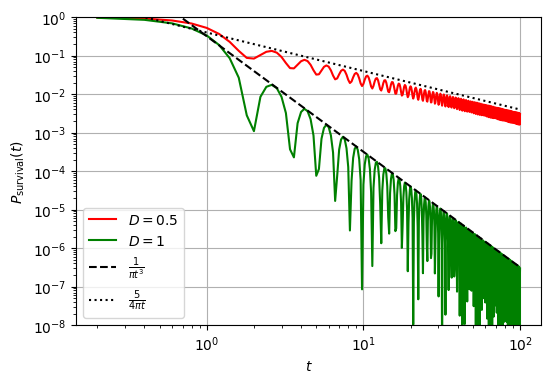

In [ ]:
def Plot_Survival_Probability_matplotlib():
    tv = np.linspace(0.2, 100, 500)  # Time values for plotting
    gamma = 1.0  # Example value for gamma
    alpha = np.pi / 2  # Example value for alpha
    P_survival_10 = P_survival(gamma, tv, 1.0, alpha)  # Example D value
    P_survival_05 = P_survival(gamma, tv, 0.5, alpha)  # Example D value
    P_survival_00 = P_survival(gamma, tv, 0.0, alpha)  # Example D value

    plt.figure(figsize=(6, 4))

    plt.plot(tv, P_survival_05, label=r'$D=0.5$', color='red')
    plt.plot(tv, P_survival_10, label=r'$D=1$', color='green')
    plt.plot(tv, 1.0/(np.pi*tv**3), label=r'$\frac{1}{\pi t^3}$', linestyle='dashed', color='black')
    plt.plot(tv, 5.0/(4*np.pi*tv), label=r'$\frac{5}{4\pi t}$', linestyle='dotted', color='black') # This line is added based on visual interpretation of the pyx plot

    plt.xscale('log')
    plt.yscale('log')

    plt.xlabel(r'$t$')
    plt.ylabel(r'$P_{\mathrm{survival}}(t)$')
    plt.ylim(10**(-8),1)
    plt.legend()
    plt.grid(True)
    plt.show()

Plot_Survival_Probability_matplotlib()

## Figure 5

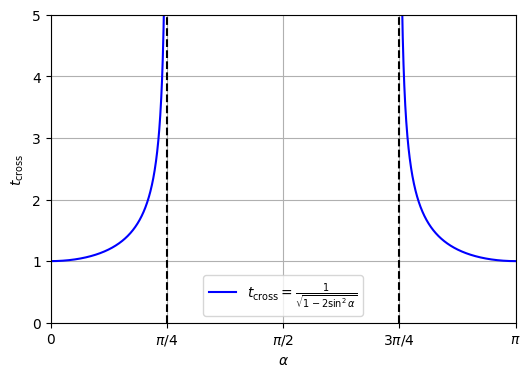

In [ ]:
def Plot_tcross_vs_alpha_simplified():
    eps = 1e-3
    npts = 600
    a1 = np.linspace(0, np.pi/4 - eps, npts)
    a2 = np.linspace(3*np.pi/4 + eps, np.pi - eps, npts)

    t1 = 1.0 / np.sqrt(1.0 - 2.0 * np.sin(a1)**2)
    t2 = 1.0 / np.sqrt(1.0 - 2.0 * np.sin(a2)**2)

    y_max = 5

    plt.figure(figsize=(6, 4))
    ax = plt.gca()

    # Plot the curves
    plt.plot(a1, t1, color='blue', label=r'$t_{\mathrm{cross}}=\frac{1}{\sqrt{1-2\sin^2\alpha}}$')
    plt.plot(a2, t2, color='blue') # No label for the second part of the curve

    # Plot asymptotes
    plt.axvline(x=np.pi/4, color='black', linestyle='dashed')
    plt.axvline(x=3*np.pi/4, color='black', linestyle='dashed')

    # Set x-axis ticks and labels to be in terms of pi
    ax.set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
    ax.set_xticklabels(['0', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$'])

    plt.xlabel(r'$\alpha$')
    plt.ylabel(r'$t_{\mathrm{cross}}$')
    plt.ylim(0, y_max)
    plt.xlim(0, np.pi)
    plt.grid(True)
    plt.legend()

    plt.show()

Plot_tcross_vs_alpha_simplified()